In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import save_image
from torchvision import transforms
from model import MNISTDiffusion
from train_mnist import create_mnist_dataloaders
from tqdm import tqdm


# Load MNIST model checkpoint and set up device
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt_path = "best_model.pt"

# MNIST Diffusion Model Parameters
in_channels = 1
time_embedding_dim = 256
timesteps = 1000
base_dim = 64
dim_mults = [2, 4]

# Instantiate the model
model = MNISTDiffusion(
    image_size=28,
    in_channels=in_channels,
    timesteps=timesteps,
    time_embedding_dim=time_embedding_dim,
    base_dim=base_dim,
    dim_mults=dim_mults,
)

# Load the trained model weights
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model = model.to(device)
model.eval()

/home/mpsenka/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MNISTDiffusion(
  (model): Unet(
    (init_conv): ConvBnSiLu(
      (module): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
    (time_embedding): Embedding(1000, 256)
    (encoder_blocks): ModuleList(
      (0): EncoderBlock(
        (conv0): Sequential(
          (0): ResidualBottleneck(
            (branch1): Sequential(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ConvBnSiLu(
                (module): Sequential(
                  (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
                  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (2): SiLU(inplace=True)
          

In [24]:
# Get a random MNIST image from the test set
_, test_dataloader = create_mnist_dataloaders(batch_size=1)
image, _ = next(iter(test_dataloader))

image2, _ = next(iter(test_dataloader))

# halfway convex interpolation

image = 0.8 * image + 0.2 * image2
image = image.to(device)

In [25]:

# Unnormalize the image for visualization
inv_normalizer = transforms.Normalize([-1.0], [2.0])
unnormalized_image = inv_normalizer(image)

# List to store norms of diffusion denoising model outputs
norms = []

# Compute norms for timesteps from 0 to 1000
t_values = torch.arange(0, timesteps, device=device)
for t in tqdm(t_values):
    t = t.unsqueeze(-1)
    # Compute model denoising output at time step t
    with torch.no_grad():
        denoised_output = model.model(image, t)
        # Compute the norm of the output
        norm = torch.norm(denoised_output).item()
        norms.append(norm)

100%|██████████| 1000/1000 [00:08<00:00, 118.41it/s]


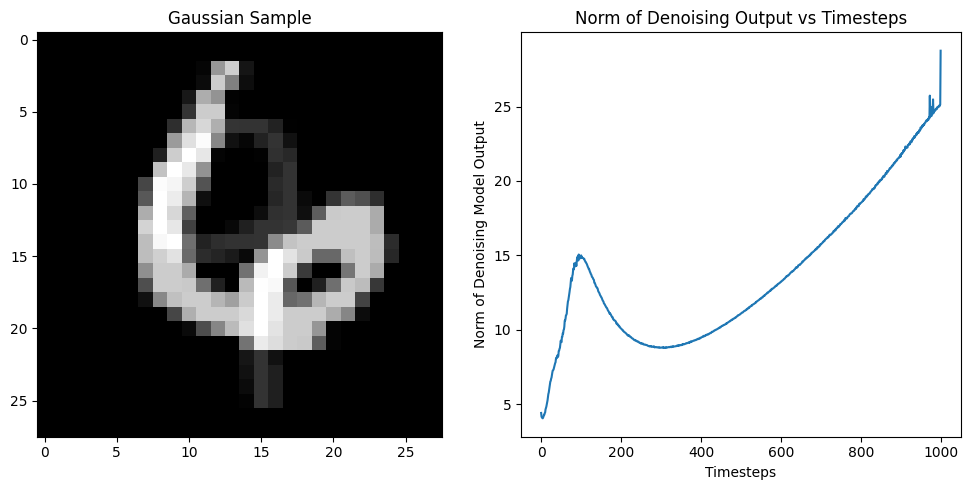

In [26]:
# Plot the image and the norm projections
plt.figure(figsize=(10, 5))

# Show the image
plt.subplot(1, 2, 1)
plt.imshow(unnormalized_image[0].cpu().numpy().squeeze(), cmap='gray')
plt.title('Gaussian Sample')

# Plot the norms
plt.subplot(1, 2, 2)
plt.plot(t_values.cpu().numpy(), norms)
plt.xlabel("Timesteps")
plt.ylabel("Norm of Denoising Model Output")
plt.title("Norm of Denoising Output vs Timesteps")

# Display the plots
plt.tight_layout()
plt.show()

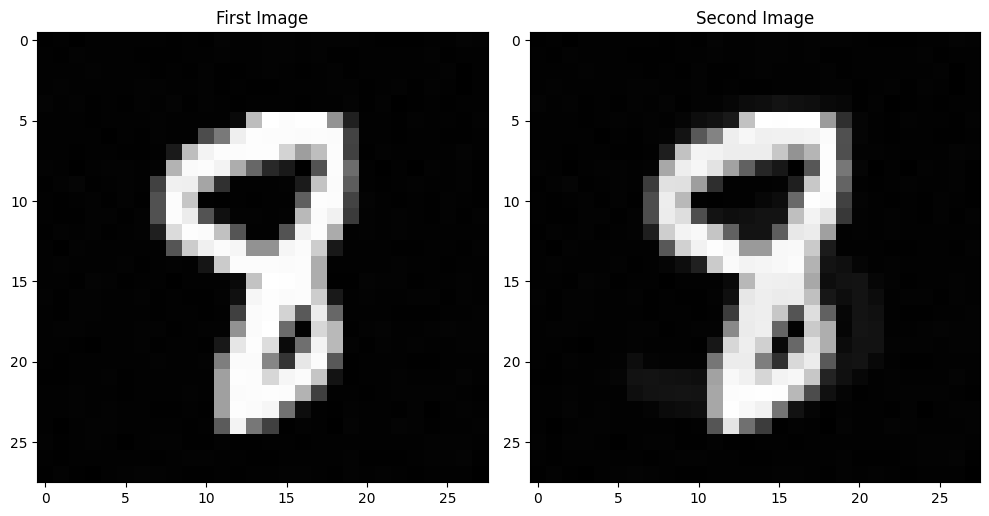

In [5]:
# load first_image_1.pt and second_image_1.pt
image1 = torch.load('first_image_0.pt')
image2 = torch.load('second_image_0.pt')
# display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1[0].detach().cpu().numpy().squeeze(), cmap='gray')
plt.title('First Image')
plt.subplot(1, 2, 2)
plt.imshow(image2[0].detach().cpu().numpy().squeeze(), cmap='gray')
plt.title('Second Image')
plt.tight_layout()
plt.show()